![alternatvie text](https://www.doc.zuv.fau.de//M/FAU-Logo/01_FAU_Kernmarke/Web/FAU_Kernmarke_Q_RGB_blue.svg)


# Assignment 1: Small Scale Data (Classification)

In this assignment basic functionalities of [PyTorch](https://docs.pytorch.org/docs/stable/index.html) will be explored for small datasets. The goal is to work on how to load images, pre-process the images and perform data augmentation. Finally, a deep neural network will be trained to perform image classification.

Note that all scripts should be self-contained and executed on *any* machine that has the required libraries installed. Moreover, you'll need to install PyTorch prior to starting this tutorial. This should be done using [Conda](https://anaconda.org/anaconda/conda). For more info. check [Install PyTorch](https://www.scaler.com/topics/pytorch/install-pytorch/) [Install PyTorch on Jupyter](https://medium.com/@kajaani1705/a-step-by-step-guide-to-using-pytorch-with-vscode-in-jupyter-notebook-f09c427f84e4)

The solutions of the assignment can be delivered as Python Notebooks or `.py` files.

## Data loading 

In this task, the data will be loaded in two different ways. At first, the `torchvision.datasets` subclasses will be used to load a dataset. Second, you will write your own dataset loader that performs the same task. In the second case, the data and labels will be loaded from the hard-drive. Alternatively, they can be loaded from the RAM memory. Both solutions are acceptable. Only the train set is required. The datasets are [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) and [MNIST](https://git-disl.github.io/GTDLBench/datasets/mnist_datasets/). Finally, the data samples and labels will be visualized. 

*Task Output*: It will be **two** different data loaders for MNIST and Fashion-MNIST. To demonstrate the data loading, the images and the corresponding labels should be vizualized. For the **visualization of the image and label**, you may use any library that you wish (e.g. [matplotlib](http://matplotlib.org/)).

*Important*: The scripts should be **self-contained**. This means that the custom dataloader should: 1. check whether the dataset is locally stored and 2. download it from the web if it not locally stored.

Tip: If it is not clear what the train / test set is when loading the data, you may check on the web-page of the dataset or on the related publication.

### a) Built-in Torch Dataloader

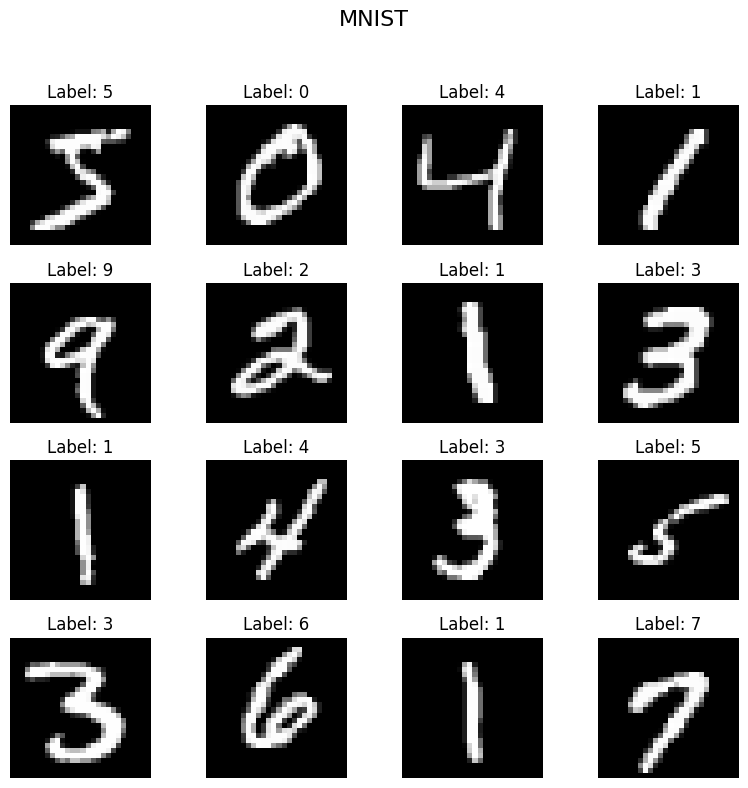

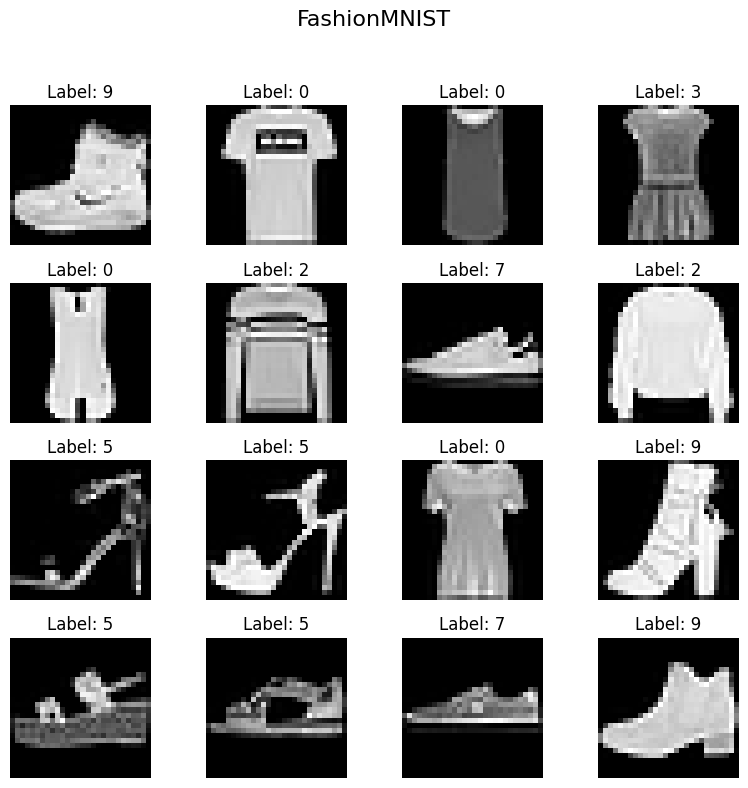

In [2]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import gzip
import struct
from pathlib import Path
import numpy as np

# TODO:
# 1. Load MNIST train/test
# Define a transform to convert images to tensors
transform = transforms.ToTensor()

# Load the training dataset
train_dataset_mnist = datasets.MNIST(root='data', train=True, download=True, transform=transform)
                               
# 2. Load FashionMNIST train/test
# Load the training dataset
train_dataset_fashion_mnist = datasets.FashionMNIST(root='data', train=True, download=True, transform=transform)

# 3. Create DataLoaders

    
# Dataloader MNIST
ROOT = "./data"

def show_dataset_grid(dataset, dataset_title, rows=4, cols=4):
    fig, axs = plt.subplots(rows, cols, figsize=(8, 8))
    fig.suptitle(dataset_title, fontsize=16)

    for i in range(rows):
        for j in range(cols):
            image, label = dataset[i * cols + j]
            image_numpy = image.numpy().squeeze()
            axs[i, j].imshow(image_numpy, cmap="gray")
            axs[i, j].axis("off")
            axs[i, j].set_title(f"Label: {label}")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

show_dataset_grid(train_dataset_mnist, "MNIST")
show_dataset_grid(train_dataset_fashion_mnist, "FashionMNIST")

### b) Customized Dataset

In this part, implement your own `torch.utils.data.Dataset` class.\
\
Your class should:
1. load images and labels,
2. implement `__len__`,
3. implement `__getitem__`,
4. implement `_download_dataset`
4. return one image-label pair at a time.

 To this end, you'll have to implement a function which downloads the datasets if it can not be found locally. You may use this download link 'https://drive.google.com/file/d/11ZiNnV3YtpZ7d9afHZg0rtDRrmhha-1E/view'.
 Also, you can rely on this documentation to handle [Gzip](https://docs.python.org/3/library/gzip.html#:~:text=To%20open%20a%20compressed%20file,and%20produces%20the%20most%20compression.) file format i.e. unzip file.\
 Additional information on CustomDataset class can be obtained here [PyTorch Dataset](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html).

MNIST: Datensatz bereits lokal vorhanden.
FashionMNIST: Datensatz bereits lokal vorhanden.
60000
60000


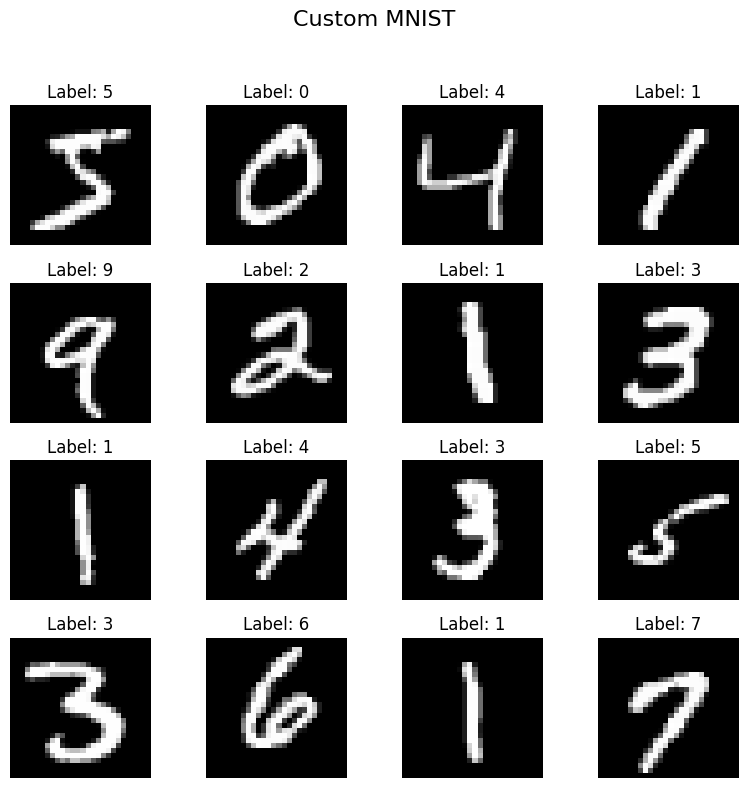

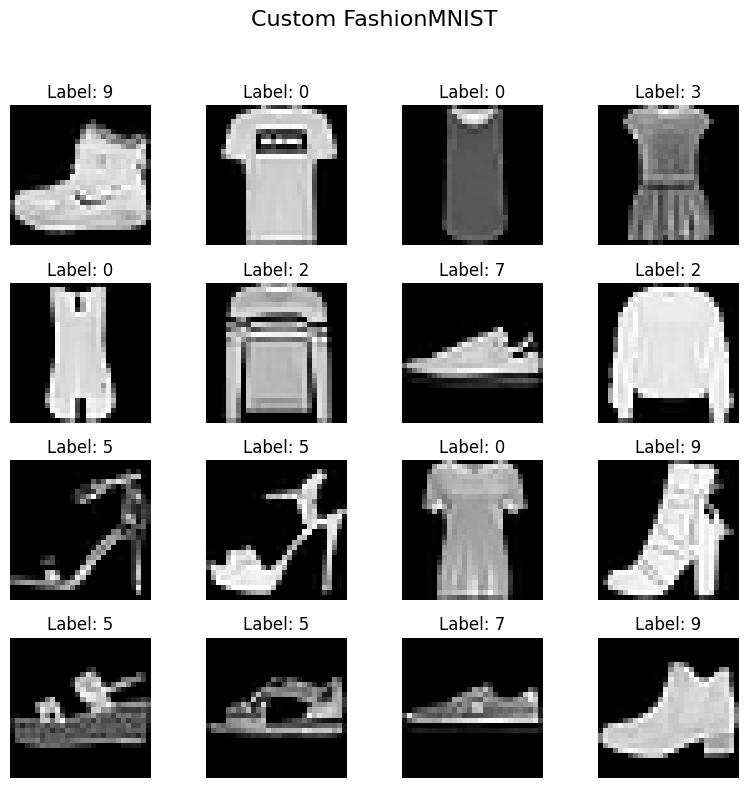

In [4]:
import torch
from torch.utils.data import Dataset

class CustomClassification(Dataset):
    def __init__(self, root, dataset_name, auto_download=True):
        self.root = Path(root)
        self.dataset_name = dataset_name

        self.raw_dir = self.root / dataset_name / "raw"
        self.images_path = self.raw_dir / "train-images-idx3-ubyte.gz"
        self.labels_path = self.raw_dir / "train-labels-idx1-ubyte.gz"

        self.images = None
        self.labels = None

        self._download_dataset(auto_download=auto_download)

    def _download_dataset(self, auto_download=True):
        if auto_download:
            self._ensure_dataset_exists()

        if not self.images_path.exists():
            raise FileNotFoundError(f"Nicht gefunden: {self.images_path}")

        if not self.labels_path.exists():
            raise FileNotFoundError(f"Nicht gefunden: {self.labels_path}")

        self.images = self._read_images(self.images_path)
        self.labels = self._read_labels(self.labels_path)

        if len(self.images) != len(self.labels):
            raise ValueError("Anzahl Bilder und Labels passt nicht zusammen.")
        
    def _ensure_dataset_exists(self):
        files_exist = self.images_path.exists() and self.labels_path.exists()

        if files_exist:
            print(f"{self.dataset_name}: Datensatz bereits lokal vorhanden.")
            return

        print(f"{self.dataset_name}: Datensatz fehlt, wird heruntergeladen...")

        if self.dataset_name == "MNIST":
            datasets.MNIST(
                root=str(self.root),
                train=True,
                download=True,
            )
        elif self.dataset_name == "FashionMNIST":
            datasets.FashionMNIST(
                root=str(self.root),
                train=True,
                download=True,
            )
        else:
            raise ValueError(
                f"Unbekannter Datensatzname: {self.dataset_name}"
            )

        print(f"{self.dataset_name}: Download abgeschlossen.")
    
    def _read_images(self, path):
        with gzip.open(path, "rb") as f:
            magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))

            if magic != 2051:
                raise ValueError(
                    f"Ungültige Magic Number für Bilder: {magic}"
                )

            data = np.frombuffer(f.read(), dtype=np.uint8)
            data = data.reshape(num_images, rows, cols)

        return data

    def _read_labels(self, path):
        with gzip.open(path, "rb") as f:
            magic, num_labels = struct.unpack(">II", f.read(8))

            if magic != 2049:
                raise ValueError(
                    f"Ungültige Magic Number für Labels: {magic}"
                )

            labels = np.frombuffer(f.read(), dtype=np.uint8)

        if len(labels) != num_labels:
            raise ValueError("Die gelesene Label-Anzahl stimmt nicht.")

        return labels
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self,idx):
        image = self.images[idx]
        label = int(self.labels[idx])

        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0) / 255.0

        return image, label
    

ROOT = "./data"

# Dataloader MNIST
mnist_train_custom = CustomClassification(ROOT, "MNIST")

# Dataloader FashionMNIST
fashion_train_custom = CustomClassification(ROOT, "FashionMNIST")

print(len(mnist_train_custom))
print(len(fashion_train_custom))


def show_dataset_grid(dataset, dataset_title, rows=4, cols=4):
    fig, axs = plt.subplots(rows, cols, figsize=(8, 8))
    fig.suptitle(dataset_title, fontsize=16)

    for i in range(rows):
        for j in range(cols):
            image, label = dataset[i * cols + j]
            image_numpy = image.numpy().squeeze()
            axs[i, j].imshow(image_numpy, cmap="gray")
            axs[i, j].axis("off")
            axs[i, j].set_title(f"Label: {label}")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


show_dataset_grid(mnist_train_custom, "Custom MNIST")
show_dataset_grid(fashion_train_custom, "Custom FashionMNIST")

## 2. Model training 

In this task, the MNIST and [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset will be employed for learning a classifier. The classifier will be a convolutional neural network. You are free to decide for the network architecture. \
Your network must include:
- at least **2 convolution layers**
- at least **1 linear layer**
- **ReLU** activations
- **CrossEntropyLoss**

Training will take place based on the train set of the dataset, also you should use part of the train set as validation and save the model with the best validation score. The test set will be used only for evaluation. Finally, the custom data-loader which has been implemented earlier will be employed here. Since there is train and test set, the data loader might need adaptation.\
\
Parameter learning: The computation of the gradients and the optimization will be based on Pytorch (`torch.optim`).

Task Output: The output will be two **figures**, where in the first figure the x - axis represents the epochs and the y-axis represents the error. The plot of the train and test set will be drawn. The second figure will show the accuracy per epoch for the train and test set. Finally, the optimization parameters (optimizer and hyper-parameters) will be reported too.


Starte Experiment für MNIST
MNIST: Datensatz bereits lokal vorhanden.
MNIST: Datensatz bereits lokal vorhanden.
Device: cuda
Epoch [1/10] | Train Loss: 0.1900, Train Acc: 0.9429 | Val Loss: 0.0655, Val Acc: 0.9825 | Test Loss: 0.0537, Test Acc: 0.9831
Epoch [2/10] | Train Loss: 0.0515, Train Acc: 0.9841 | Val Loss: 0.0607, Val Acc: 0.9810 | Test Loss: 0.0458, Test Acc: 0.9851
Epoch [3/10] | Train Loss: 0.0373, Train Acc: 0.9881 | Val Loss: 0.0570, Val Acc: 0.9833 | Test Loss: 0.0444, Test Acc: 0.9865
Epoch [4/10] | Train Loss: 0.0297, Train Acc: 0.9904 | Val Loss: 0.0420, Val Acc: 0.9870 | Test Loss: 0.0306, Test Acc: 0.9899
Epoch [5/10] | Train Loss: 0.0241, Train Acc: 0.9924 | Val Loss: 0.0418, Val Acc: 0.9887 | Test Loss: 0.0302, Test Acc: 0.9901
Epoch [6/10] | Train Loss: 0.0199, Train Acc: 0.9937 | Val Loss: 0.0405, Val Acc: 0.9878 | Test Loss: 0.0306, Test Acc: 0.9902
Epoch [7/10] | Train Loss: 0.0182, Train Acc: 0.9939 | Val Loss: 0.0468, Val Acc: 0.9880 | Test Loss: 0.0337, Te

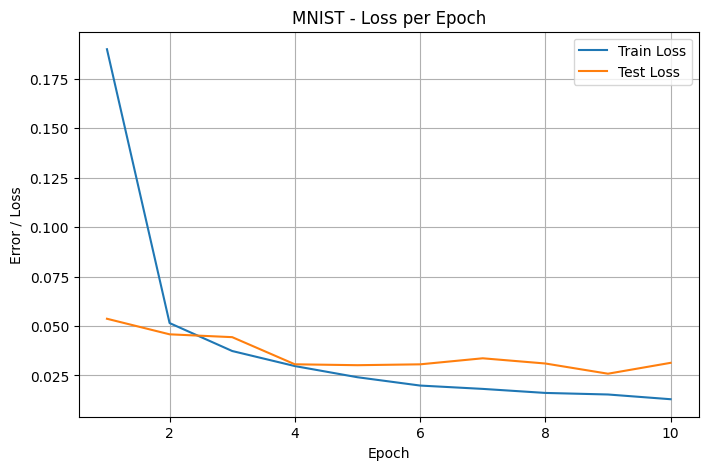

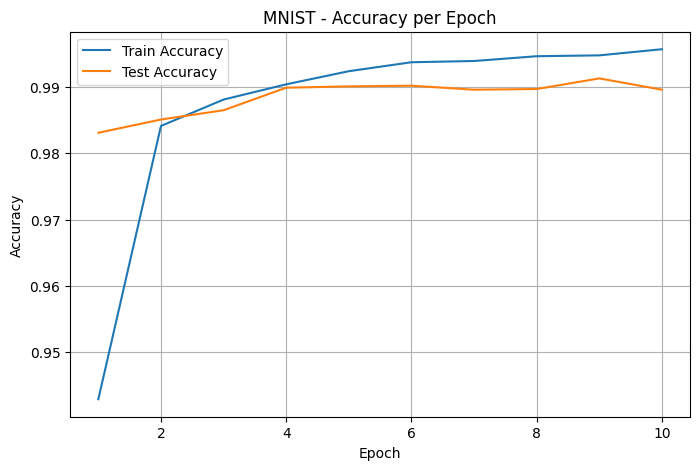

MNIST Hyperparameter:
optimizer: Adam
learning_rate: 0.001
weight_decay: 0.0001
batch_size: 64
epochs: 10
loss_function: CrossEntropyLoss

Starte Experiment für FashionMNIST
FashionMNIST: Datensatz bereits lokal vorhanden.
FashionMNIST: Datensatz bereits lokal vorhanden.
Device: cuda
Epoch [1/10] | Train Loss: 0.4747, Train Acc: 0.8270 | Val Loss: 0.3512, Val Acc: 0.8740 | Test Loss: 0.3630, Test Acc: 0.8723
Epoch [2/10] | Train Loss: 0.3097, Train Acc: 0.8881 | Val Loss: 0.3256, Val Acc: 0.8828 | Test Loss: 0.3424, Test Acc: 0.8797
Epoch [3/10] | Train Loss: 0.2695, Train Acc: 0.9024 | Val Loss: 0.2996, Val Acc: 0.8910 | Test Loss: 0.3123, Test Acc: 0.8877
Epoch [4/10] | Train Loss: 0.2386, Train Acc: 0.9119 | Val Loss: 0.2560, Val Acc: 0.9038 | Test Loss: 0.2735, Test Acc: 0.9015
Epoch [5/10] | Train Loss: 0.2157, Train Acc: 0.9197 | Val Loss: 0.2439, Val Acc: 0.9113 | Test Loss: 0.2552, Test Acc: 0.9065
Epoch [6/10] | Train Loss: 0.1971, Train Acc: 0.9270 | Val Loss: 0.2291, Val Acc

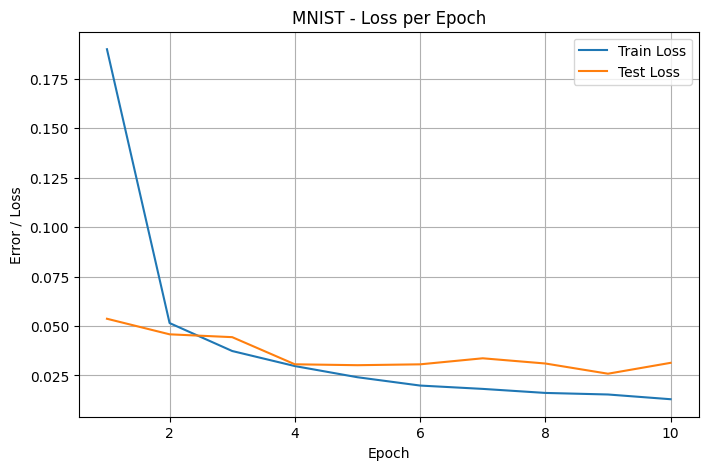

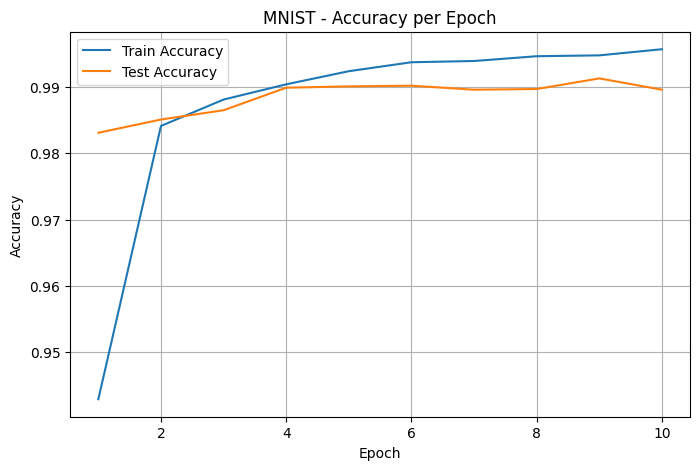

MNIST Hyperparameter:
optimizer: Adam
learning_rate: 0.001
weight_decay: 0.0001
batch_size: 64
epochs: 10
loss_function: CrossEntropyLoss


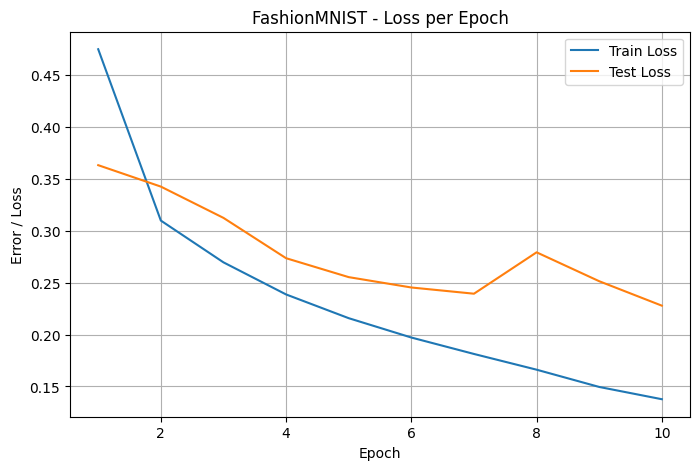

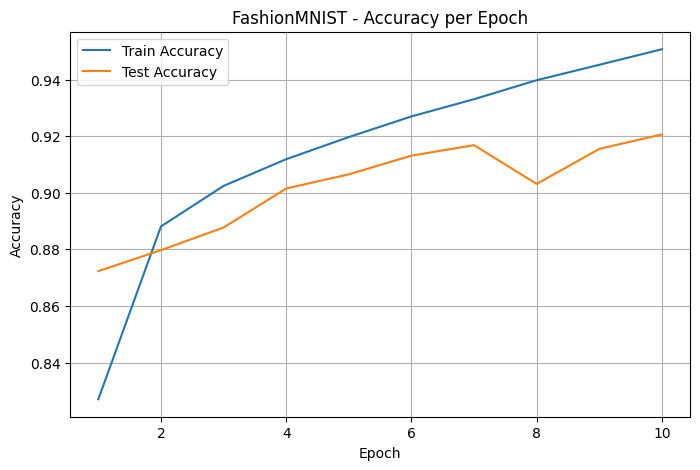

FashionMNIST Hyperparameter:
optimizer: Adam
learning_rate: 0.001
weight_decay: 0.0001
batch_size: 64
epochs: 10
loss_function: CrossEntropyLoss


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split


class CustomClassificationTraining(Dataset):
    def __init__(
        self,
        root,
        dataset_name,
        train=True,
        auto_download=True,
    ):
        self.root = Path(root)
        self.dataset_name = dataset_name
        self.train = train

        self.raw_dir = self.root / dataset_name / "raw"

        if self.train:
            self.images_path = self.raw_dir / "train-images-idx3-ubyte.gz"
            self.labels_path = self.raw_dir / "train-labels-idx1-ubyte.gz"
        else:
            self.images_path = self.raw_dir / "t10k-images-idx3-ubyte.gz"
            self.labels_path = self.raw_dir / "t10k-labels-idx1-ubyte.gz"

        self.images = None
        self.labels = None

        self._load_dataset(auto_download=auto_download)

    def _load_dataset(self, auto_download=True):
        if auto_download:
            self._ensure_dataset_exists()

        if not self.images_path.exists():
            raise FileNotFoundError(f"Nicht gefunden: {self.images_path}")

        if not self.labels_path.exists():
            raise FileNotFoundError(f"Nicht gefunden: {self.labels_path}")

        self.images = self._read_images(self.images_path)
        self.labels = self._read_labels(self.labels_path)

        if len(self.images) != len(self.labels):
            raise ValueError("Anzahl Bilder und Labels passt nicht zusammen.")

    def _ensure_dataset_exists(self):
        required_files = [
            self.raw_dir / "train-images-idx3-ubyte.gz",
            self.raw_dir / "train-labels-idx1-ubyte.gz",
            self.raw_dir / "t10k-images-idx3-ubyte.gz",
            self.raw_dir / "t10k-labels-idx1-ubyte.gz",
        ]

        if all(path.exists() for path in required_files):
            print(f"{self.dataset_name}: Datensatz bereits lokal vorhanden.")
            return

        print(f"{self.dataset_name}: Datensatz fehlt, wird heruntergeladen...")

        if self.dataset_name == "MNIST":
            datasets.MNIST(
                root=str(self.root),
                train=True,
                download=True,
            )
            datasets.MNIST(
                root=str(self.root),
                train=False,
                download=True,
            )
        elif self.dataset_name == "FashionMNIST":
            datasets.FashionMNIST(
                root=str(self.root),
                train=True,
                download=True,
            )
            datasets.FashionMNIST(
                root=str(self.root),
                train=False,
                download=True,
            )
        else:
            raise ValueError(
                f"Unbekannter Datensatzname: {self.dataset_name}"
            )

        print(f"{self.dataset_name}: Download abgeschlossen.")

    def _read_images(self, path):
        with gzip.open(path, "rb") as f:
            magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))

            if magic != 2051:
                raise ValueError(
                    f"Ungültige Magic Number für Bilder: {magic}"
                )

            data = np.frombuffer(f.read(), dtype=np.uint8)
            data = data.reshape(num_images, rows, cols)

        return data

    def _read_labels(self, path):
        with gzip.open(path, "rb") as f:
            magic, num_labels = struct.unpack(">II", f.read(8))

            if magic != 2049:
                raise ValueError(
                    f"Ungültige Magic Number für Labels: {magic}"
                )

            labels = np.frombuffer(f.read(), dtype=np.uint8)

        if len(labels) != num_labels:
            raise ValueError("Die gelesene Label-Anzahl stimmt nicht.")

        return labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = int(self.labels[idx])

        image = (
            torch.tensor(image, dtype=torch.float32)
            .unsqueeze(0) / 255.0
        )

        return image, label

# Implement your network

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1,
        )
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1,
        )

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 28x28 -> 14x14
        x = self.pool(F.relu(self.conv2(x)))   # 14x14 -> 7x7

        x = torch.flatten(x, start_dim=1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Train
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# Test
@torch.no_grad() #No calculation or saving of gradients for following function
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# Show figures
def run_experiment(
    dataset_name,
    root="./data",
    batch_size=64,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    val_ratio=0.1,
    seed=42,
):
    print(f"\nStarte Experiment für {dataset_name}")

    # Datensätze
    full_train_dataset = CustomClassificationTraining(
        root=root,
        dataset_name=dataset_name,
        train=True,
        auto_download=True,
    )

    test_dataset = CustomClassificationTraining(
        root=root,
        dataset_name=dataset_name,
        train=False,
        auto_download=True,
    )

    # Train / Validation Split
    val_size = int(len(full_train_dataset) * val_ratio)
    train_size = len(full_train_dataset) - val_size

    generator = torch.Generator().manual_seed(seed)

    train_dataset, val_dataset = random_split(
        full_train_dataset,
        [train_size, val_size],
        generator=generator,
    )

    # DataLoader
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    # Device
    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )
    print(f"Device: {device}")

    # Modell, Loss, Optimizer
    model = SimpleCNN(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    # History
    history = {
        "train_loss": [],
        "val_loss": [],
        "test_loss": [],
        "train_acc": [],
        "val_acc": [],
        "test_acc": [],
    }

    best_val_acc = 0.0
    best_model_path = f"best_{dataset_name.lower()}.pth"

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
        )

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion,
            device,
        )

        # Nur fürs Logging/Plotting pro Epoche
        test_loss, test_acc = evaluate(
            model,
            test_loader,
            criterion,
            device,
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["test_loss"].append(test_loss)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["test_acc"].append(test_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)

        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
            f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
        )

    # Bestes Modell laden
    model.load_state_dict(torch.load(best_model_path, map_location=device))

    final_test_loss, final_test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device,
    )

    print(f"\nBestes Modell gespeichert unter: {best_model_path}")
    print(f"Beste Validation Accuracy: {best_val_acc:.4f}")
    print(f"Final Test Loss: {final_test_loss:.4f}")
    print(f"Final Test Accuracy: {final_test_acc:.4f}")

    config = {
        "optimizer": "Adam",
        "learning_rate": lr,
        "weight_decay": weight_decay,
        "batch_size": batch_size,
        "epochs": epochs,
        "loss_function": "CrossEntropyLoss",
    }

    return model, history, config

def plot_history(history, dataset_name):
    epochs = range(1, len(history["train_loss"]) + 1)

    # Figure 1: Loss / Error
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Error / Loss")
    plt.title(f"{dataset_name} - Loss per Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Figure 2: Accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["test_acc"], label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{dataset_name} - Accuracy per Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()


mnist_model, mnist_history, mnist_config = run_experiment(
    dataset_name="MNIST",
    root="./data",
    batch_size=64,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
)

plot_history(mnist_history, "MNIST")

print("MNIST Hyperparameter:")
for key, value in mnist_config.items():
    print(f"{key}: {value}")

fashion_model, fashion_history, fashion_config = run_experiment(
    dataset_name="FashionMNIST",
    root="./data",
    batch_size=64,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
)

plot_history(mnist_history, "MNIST")

print("MNIST Hyperparameter:")
for key, value in mnist_config.items():
    print(f"{key}: {value}")

plot_history(fashion_history, "FashionMNIST")

print("FashionMNIST Hyperparameter:")
for key, value in fashion_config.items():
    print(f"{key}: {value}")

## 3. Data Augmentation


The datasets [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) and [MNIST](http://yann.lecun.com/exdb/mnist/) will be the testbed to investigate the impact of data augmentation. The source code from the last assignment can be used for data loading and model training. The network architecture can be the same from the last assignment as well. The data loading and augmentation can be done using the modules `torch.utils.data` and `torchvision`. Moreover, the dataset can be loaded from PyTorch class from each dataset.
 
*Task Output*: The required augmentation for this task is random affine with degree set to 20, translate (0.1,0.1) and scale (0.9,1.1). Moreover, color jitter should be applied on top with brightness set to 0.2 and also contrast to 0.2. At first, a model without augmentation should be trained. The performance on the test set will be the output of the task. Second, a model with data augmentation should be trained. The new performance on test will be now reported and compared to the accuracy without data augmentation.

*Important*: The scripts should be **self-contained**. The data augmentation should be dynamically implemented, i.e it is applied when the data from the mini-batch is loaded.

In [ ]:
from torchvision import transforms
from torch.utils.data import Subset


train_transform_aug = transforms.Compose([
    transforms.RandomAffine(
        degrees=20,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
    ),
])

class CustomClassification3(Dataset):
    def __init__(
        self,
        root,
        dataset_name,
        train=True,
        auto_download=True,
        transform=None,
    ):
        self.root = Path(root)
        self.dataset_name = dataset_name
        self.train = train
        self.transform = transform

        self.raw_dir = self.root / dataset_name / "raw"

        if self.train:
            self.images_path = self.raw_dir / "train-images-idx3-ubyte.gz"
            self.labels_path = self.raw_dir / "train-labels-idx1-ubyte.gz"
        else:
            self.images_path = self.raw_dir / "t10k-images-idx3-ubyte.gz"
            self.labels_path = self.raw_dir / "t10k-labels-idx1-ubyte.gz"

        self.images = None
        self.labels = None

        self._load_dataset(auto_download=auto_download)

    def _load_dataset(self, auto_download=True):
        if auto_download:
            self._ensure_dataset_exists()

        if not self.images_path.exists():
            raise FileNotFoundError(f"Nicht gefunden: {self.images_path}")

        if not self.labels_path.exists():
            raise FileNotFoundError(f"Nicht gefunden: {self.labels_path}")

        self.images = self._read_images(self.images_path)
        self.labels = self._read_labels(self.labels_path)

        if len(self.images) != len(self.labels):
            raise ValueError("Anzahl Bilder und Labels passt nicht zusammen.")

    def _ensure_dataset_exists(self):
        required_files = [
            self.raw_dir / "train-images-idx3-ubyte.gz",
            self.raw_dir / "train-labels-idx1-ubyte.gz",
            self.raw_dir / "t10k-images-idx3-ubyte.gz",
            self.raw_dir / "t10k-labels-idx1-ubyte.gz",
        ]

        if all(path.exists() for path in required_files):
            print(f"{self.dataset_name}: Datensatz bereits lokal vorhanden.")
            return

        print(f"{self.dataset_name}: Datensatz fehlt, wird heruntergeladen...")

        if self.dataset_name == "MNIST":
            datasets.MNIST(
                root=str(self.root),
                train=True,
                download=True,
            )
            datasets.MNIST(
                root=str(self.root),
                train=False,
                download=True,
            )
        elif self.dataset_name == "FashionMNIST":
            datasets.FashionMNIST(
                root=str(self.root),
                train=True,
                download=True,
            )
            datasets.FashionMNIST(
                root=str(self.root),
                train=False,
                download=True,
            )
        else:
            raise ValueError(
                f"Unbekannter Datensatzname: {self.dataset_name}"
            )

        print(f"{self.dataset_name}: Download abgeschlossen.")

    def _read_images(self, path):
        with gzip.open(path, "rb") as f:
            magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))

            if magic != 2051:
                raise ValueError(
                    f"Ungültige Magic Number für Bilder: {magic}"
                )

            data = np.frombuffer(f.read(), dtype=np.uint8)
            data = data.reshape(num_images, rows, cols)

        return data

    def _read_labels(self, path):
        with gzip.open(path, "rb") as f:
            magic, num_labels = struct.unpack(">II", f.read(8))

            if magic != 2049:
                raise ValueError(
                    f"Ungültige Magic Number für Labels: {magic}"
                )

            labels = np.frombuffer(f.read(), dtype=np.uint8)

        if len(labels) != num_labels:
            raise ValueError("Die gelesene Label-Anzahl stimmt nicht.")

        return labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = int(self.labels[idx])

        image = (
            torch.tensor(image, dtype=torch.float32).unsqueeze(0) / 255.0
        )

        if self.transform is not None:
            image = self.transform(image)

        return image, label
    
def run_experiment3(
    train_loader,
    val_loader,
    test_loader,
    model,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    device=None,
    model_path="best_model.pth",
    evaluate_test_each_epoch=True,
):
    if device is None:
        device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "test_loss": [],
        "train_acc": [],
        "val_acc": [],
        "test_acc": [],
    }

    best_val_acc = 0.0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )

        val_loss, val_acc = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
        )

        if evaluate_test_each_epoch:
            test_loss, test_acc = evaluate(
                model=model,
                loader=test_loader,
                criterion=criterion,
                device=device,
            )
        else:
            test_loss, test_acc = None, None

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if evaluate_test_each_epoch:
            history["test_loss"].append(test_loss)
            history["test_acc"].append(test_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), model_path)

        if evaluate_test_each_epoch:
            print(
                f"Epoch [{epoch + 1}/{epochs}] | "
                f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
                f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
            )
        else:
            print(
                f"Epoch [{epoch + 1}/{epochs}] | "
                f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
            )

    model.load_state_dict(torch.load(model_path, map_location=device))

    final_test_loss, final_test_acc = evaluate(
        model=model,
        loader=test_loader,
        criterion=criterion,
        device=device,
    )

    print(f"\nBestes Modell gespeichert unter: {model_path}")
    print(f"Beste Validation Accuracy: {best_val_acc:.4f}")
    print(f"Final Test Loss: {final_test_loss:.4f}")
    print(f"Final Test Accuracy: {final_test_acc:.4f}")

    config = {
        "optimizer": "Adam",
        "learning_rate": lr,
        "weight_decay": weight_decay,
        "epochs": epochs,
        "loss_function": "CrossEntropyLoss",
        "device": str(device),
    }

    return model, history, config

#------------------------------------Dataset MNIST--------------------------------------------

mnist_train_plain_full = CustomClassification3(
    root="./data",
    dataset_name="MNIST",
    train=True,
    transform=None,
)

mnist_train_aug_full = CustomClassification3(
    root="./data",
    dataset_name="MNIST",
    train=True,
    transform=train_transform_aug,
)

mnist_test = CustomClassification3(
    root="./data",
    dataset_name="MNIST",
    train=False,
    transform=None,
)

#--------------------------------------------------------------------------------
#------------------------------------Dataset FashionMNIST--------------------------------------------

fashion_train_plain_full = CustomClassification3(
    root="./data",
    dataset_name="FashionMNIST",
    train=True,
    transform=None,
)

fashion_train_aug_full = CustomClassification3(
    root="./data",
    dataset_name="FashionMNIST",
    train=True,
    transform=train_transform_aug,
)

fashion_test = CustomClassification3(
    root="./data",
    dataset_name="FashionMNIST",
    train=False,
    transform=None,
)

#--------------------------------------------------------------------------------
#------------------------------------Fixed Indices--------------------------------------------

seed = 42
generator = torch.Generator().manual_seed(seed)

num_samples = len(mnist_train_plain_full)
val_ratio = 0.1
val_size = int(num_samples * val_ratio)
train_size = num_samples - val_size

indices = torch.randperm(num_samples, generator=generator).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

#--------------------------------------------------------------------------------
#------------------------------------Fixed Splits--------------------------------------------

train_plain = Subset(mnist_train_plain_full, train_indices)
train_aug = Subset(mnist_train_aug_full, train_indices)
val_set = Subset(mnist_train_plain_full, val_indices)

fashion_train_plain = Subset(fashion_train_plain_full, train_indices)
fashion_train_aug = Subset(fashion_train_aug_full, train_indices)
fashion_val_set = Subset(fashion_train_plain_full, val_indices)

#--------------------------------------------------------------------------------
#------------------------------------Fixed Loader--------------------------------------------

train_loader_plain = DataLoader(train_plain, batch_size=64, shuffle=True)
train_loader_aug = DataLoader(train_aug, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)
test_loader = DataLoader(mnist_test, batch_size=64, shuffle=False)

#--------------------------------------------------------------------------------
#------------------------------------Training without Augmentation--------------------------------------------

model_plain = SimpleCNN(num_classes=10)

model_plain, history_plain, config_plain = run_experiment3(
    train_loader=train_loader_plain,
    val_loader=val_loader,
    test_loader=test_loader,
    model=model_plain,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    model_path="best_mnist_plain.pth",
)

#--------------------------------------------------------------------------------
#------------------------------------Training with Augmentation--------------------------------------------

model_aug = SimpleCNN(num_classes=10)

model_aug, history_aug, config_aug = run_experiment3(
    train_loader=train_loader_aug,
    val_loader=val_loader,
    test_loader=test_loader,
    model=model_aug,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    model_path="best_mnist_aug.pth",
)

#--------------------------------------------------------------------------------
#------------------------------------Plot Results--------------------------------------------

def plot_history3(history, title, use_test=True):
    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")

    if use_test and len(history["test_loss"]) > 0:
        plt.plot(epochs, history["test_loss"], label="Test Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss per Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")

    if use_test and len(history["test_acc"]) > 0:
        plt.plot(epochs, history["test_acc"], label="Test Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy per Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()